# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №1, part 2
## Gradient boosting on temporal data and feature importances

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

By default we will work with widely known [Human Actividy Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Data is available at UCI repository.

There are available both raw and preprocessed datasets. This time we will use the preprocessed one.
Some simple preprocessing is done for you.

If you want more interpretable data, you can take [Wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) (see details below).

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

_Despite the main language of this notebook is English, feel free to write your thoughts in Russian._

In [59]:
#!pip install catboost



In [60]:
import catboost

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [61]:
# Download and unpack dataset from UCI
#!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
#!unzip -u "UCI HAR Dataset.zip" "UCI HAR Dataset/train/X_train.txt" "UCI HAR Dataset/train/y_train.txt" \
#"UCI HAR Dataset/test/X_test.txt" "UCI HAR Dataset/test/y_test.txt" "UCI HAR Dataset/activity_labels.txt"

In [62]:
import matplotlib.pyplot as plt
import numpy as np

In [63]:
X_train = np.genfromtxt("UCI HAR Dataset/train/X_train.txt")
y_train = np.genfromtxt("UCI HAR Dataset/train/y_train.txt")
print(f"Train set: {X_train.shape}, {y_train.shape}")

X_test = np.genfromtxt("UCI HAR Dataset/test/X_test.txt")
y_test = np.genfromtxt("UCI HAR Dataset/test/y_test.txt")
print(f"Test set: {X_test.shape}, {y_test.shape}")

n_features = X_train.shape[1]

KeyboardInterrupt: 

In [4]:
activity_labels = {}
with open("UCI HAR Dataset/activity_labels.txt", "r") as file:
    for line in file:
        label, name = line.strip().split(" ")
        activity_labels[int(label)] = name

activity_labels

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

Let's normalize data

In [5]:
data_mean = X_train.mean(axis=0)
data_std = X_train.std(axis=0)

X_train = (X_train - data_mean) / data_std
X_test = (X_test - data_mean) / data_std

The dataset has some duplicating features. Let's remove them

In [6]:
# fmt: off
duplicating_columns = (
    205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 231, 244, 257, 507, 520, 533, 546,
)
# fmt: on

duplicating_mask = np.isin(range(n_features), duplicating_columns)

In [10]:
X_train_unique = X_train[:, ~duplicating_mask]
X_test_unique = X_test[:, ~duplicating_mask]

X_train_unique.shape, X_test_unique.shape

((7352, 540), (2947, 540))

PCA could be useful in this case. E.g.

In [8]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train_unique)
X_test_pca = pca.transform(X_test_unique)

X_train_pca.shape, X_test_pca.shape

((7352, 179), (2947, 179))

In [ ]:
# TODO example of data (X, Y) where target equals X, Y is independent of X, but variance of Y is much higher than that of X and X gets discarded

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


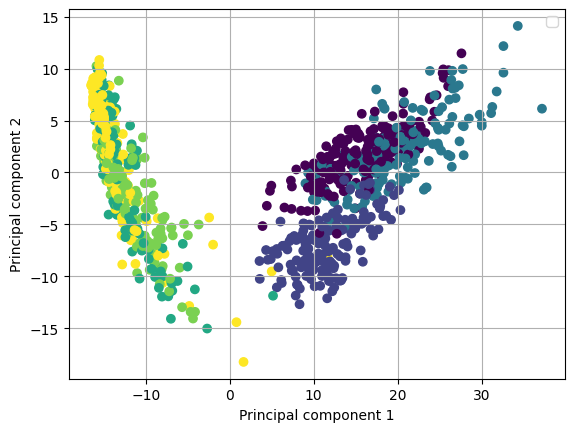

In [ ]:
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.legend()

Text(0, 0.5, 'Principal component 5')

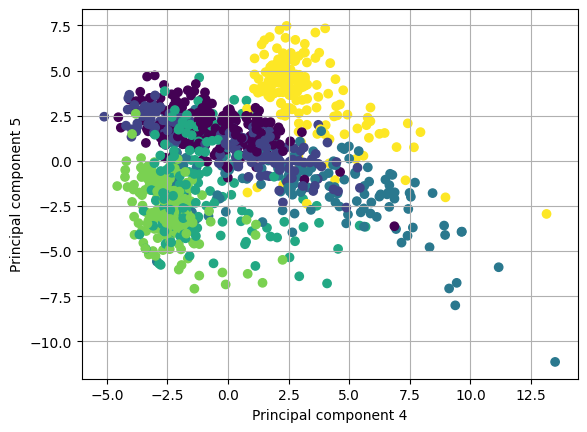

In [13]:
plt.scatter(X_train_pca[:1000, 3], X_train_pca[:1000, 4], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 4")
plt.ylabel("Principal component 5")

### Alternative dataset: Wine quality

Please, take this dataset if you are sure you can preprocess it yourself and ready to work with it's features and results, so it is done on your risk.

However you will have interpretable features which can be analysed with shap in last part

In [14]:
#!pip install ucimlrepo

In [15]:
import ucimlrepo as uci

In [16]:
dataset = uci.fetch_ucirepo(id=186)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

Wine Quality 

Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/). 

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to t

## Part 1. Fit the model.

Despite optimal parameters (e.g. for xgboost) can be found on the web, we still want you to approximate them by yourself.

In this part just check some (3-5) sets of hyperparameters by hand.

In [17]:
# YOUR CODE HERE

# Example: https://rpubs.com/burakh/har_xgb

In [18]:
train_data = X_train_pca
train_labels = y_train

test_data = X_test_pca
test_labels = y_test

In [28]:
test_data.shape

(2947, 179)

In [29]:
from sklearn.model_selection import train_test_split

test_data, val_data, test_labels, val_labels = train_test_split(
    test_data, test_labels, test_size=0.2, shuffle=True
)

In [31]:
test_data.shape,val_data.shape,  

((2357, 179), (590, 179))

In [44]:
model = CatBoostClassifier(iterations=2,
                        depth=2,
                        learning_rate=1,
                        loss_function='MultiClass',
                        verbose=True)
# train the model
model.fit(train_data, train_labels)
# make the prediction using the resulting model
preds_class = model.predict(test_data)
preds_proba = model.predict_proba(test_data)

print(dict(model.get_metadata())['training'])

0:	learn: 0.9910110	total: 8.6ms	remaining: 8.6ms
1:	learn: 0.8219137	total: 15.7ms	remaining: 0us
{"metrics":{"learn_best_error":{"MultiClass":0.8219137009842136},"test_metrics_history":[],"learn_metrics_history":[{"MultiClass":0.9910109829768942},{"MultiClass":0.8219137009842136}],"test_best_error":[]}}


In [45]:
print(*dict(model.get_metadata()).keys(), sep='\n')

catboost_version_info
train_finish_time
class_params
output_options
training
model_guid
params


In [115]:
import numpy as np

from catboost import CatBoostClassifier

def try_params(
                           it=2,
                           h=2,
                           eta=1,
                           lam=0,
                           verbose=True,
                           test=True
):
  model = CatBoostClassifier(iterations=it,
                           depth=h,
                           learning_rate=eta,
                           loss_function='MultiClass',
                           verbose=verbose,
                           l2_leaf_reg=lam)
  # train the model
  model.fit(train_data, train_labels)
  # make the prediction using the resulting model
  pred_data = val_data
  pred_labels = val_labels
  if test:
    pred_data = test_data
    pred_labels = test_labels

  preds_class = model.predict(pred_data)
  preds_proba = model.predict_proba(pred_data)
  if verbose:
    print("class = ", preds_class)
    print("proba = ", preds_proba)
  err = 0
  n = len(preds_class)
  for i in range(n):
    if pred_labels[i] != preds_class[i][0]:
      err += 1
  if verbose:
    print("err / n = ", err/n)
    print(dict(model.get_metadata())['training'])
  return model

### manual tests

In [67]:
try_params()

0:	learn: 0.9910110	total: 8.15ms	remaining: 8.15ms
1:	learn: 0.8219137	total: 16ms	remaining: 0us
class =  [[1.]
 [6.]
 [6.]
 [2.]
 [1.]
 [6.]
 [2.]
 [4.]
 [4.]
 [5.]
 [3.]
 [3.]
 [1.]
 [3.]
 [3.]
 [4.]
 [2.]
 [6.]
 [6.]
 [1.]
 [5.]
 [4.]
 [1.]
 [1.]
 [3.]
 [3.]
 [1.]
 [6.]
 [3.]
 [4.]
 [6.]
 [4.]
 [6.]
 [3.]
 [4.]
 [1.]
 [3.]
 [2.]
 [3.]
 [4.]
 [6.]
 [2.]
 [1.]
 [3.]
 [6.]
 [3.]
 [4.]
 [2.]
 [2.]
 [3.]
 [2.]
 [4.]
 [3.]
 [4.]
 [5.]
 [2.]
 [1.]
 [2.]
 [3.]
 [6.]
 [6.]
 [6.]
 [1.]
 [3.]
 [4.]
 [2.]
 [4.]
 [4.]
 [5.]
 [2.]
 [4.]
 [4.]
 [2.]
 [3.]
 [4.]
 [1.]
 [3.]
 [2.]
 [4.]
 [5.]
 [4.]
 [1.]
 [3.]
 [4.]
 [4.]
 [1.]
 [2.]
 [3.]
 [1.]
 [4.]
 [6.]
 [6.]
 [1.]
 [2.]
 [4.]
 [2.]
 [6.]
 [4.]
 [5.]
 [1.]
 [4.]
 [3.]
 [4.]
 [3.]
 [4.]
 [5.]
 [4.]
 [5.]
 [4.]
 [4.]
 [4.]
 [2.]
 [1.]
 [4.]
 [4.]
 [4.]
 [4.]
 [2.]
 [3.]
 [3.]
 [4.]
 [4.]
 [2.]
 [1.]
 [6.]
 [1.]
 [4.]
 [1.]
 [4.]
 [6.]
 [2.]
 [3.]
 [4.]
 [6.]
 [2.]
 [6.]
 [4.]
 [4.]
 [1.]
 [4.]
 [6.]
 [4.]
 [6.]
 [1.]
 [4.]
 [3.]
 [3.]
 [4.]
 [5.

In [68]:
try_params(
    it=6,
    h=2,
    eta=1,
)

0:	learn: 0.9910110	total: 8.31ms	remaining: 41.5ms
1:	learn: 0.8219137	total: 15.6ms	remaining: 31.3ms
2:	learn: 0.7218811	total: 22.8ms	remaining: 22.8ms
3:	learn: 0.6600318	total: 30.4ms	remaining: 15.2ms
4:	learn: 0.6107211	total: 36.8ms	remaining: 7.36ms
5:	learn: 0.5696312	total: 44.4ms	remaining: 0us
class =  [[1.]
 [6.]
 [6.]
 [2.]
 [1.]
 [6.]
 [2.]
 [5.]
 [5.]
 [5.]
 [3.]
 [3.]
 [1.]
 [3.]
 [3.]
 [5.]
 [2.]
 [6.]
 [6.]
 [1.]
 [5.]
 [5.]
 [1.]
 [1.]
 [1.]
 [3.]
 [1.]
 [6.]
 [1.]
 [4.]
 [6.]
 [5.]
 [6.]
 [1.]
 [5.]
 [1.]
 [1.]
 [2.]
 [3.]
 [5.]
 [6.]
 [2.]
 [1.]
 [3.]
 [6.]
 [1.]
 [5.]
 [2.]
 [2.]
 [3.]
 [2.]
 [5.]
 [3.]
 [5.]
 [4.]
 [2.]
 [1.]
 [2.]
 [3.]
 [6.]
 [6.]
 [6.]
 [1.]
 [3.]
 [5.]
 [2.]
 [4.]
 [4.]
 [4.]
 [2.]
 [5.]
 [5.]
 [2.]
 [1.]
 [5.]
 [1.]
 [3.]
 [3.]
 [4.]
 [6.]
 [5.]
 [1.]
 [3.]
 [5.]
 [4.]
 [1.]
 [2.]
 [1.]
 [1.]
 [4.]
 [6.]
 [6.]
 [1.]
 [2.]
 [4.]
 [2.]
 [6.]
 [5.]
 [5.]
 [1.]
 [5.]
 [3.]
 [5.]
 [3.]
 [5.]
 [5.]
 [4.]
 [5.]
 [4.]
 [5.]
 [5.]
 [2.]
 [1.]
 [5.

In [69]:
try_params(
    it=10,
    h=6,
    eta=0.3
    ,
)

0:	learn: 1.1685758	total: 97.2ms	remaining: 875ms
1:	learn: 0.9091955	total: 183ms	remaining: 730ms
2:	learn: 0.7651073	total: 273ms	remaining: 636ms
3:	learn: 0.6729246	total: 360ms	remaining: 540ms
4:	learn: 0.5997000	total: 443ms	remaining: 443ms
5:	learn: 0.5435621	total: 520ms	remaining: 347ms
6:	learn: 0.4985474	total: 605ms	remaining: 259ms
7:	learn: 0.4625908	total: 693ms	remaining: 173ms
8:	learn: 0.4274054	total: 776ms	remaining: 86.2ms
9:	learn: 0.4044939	total: 850ms	remaining: 0us
class =  [[1.]
 [6.]
 [4.]
 [1.]
 [1.]
 [6.]
 [2.]
 [4.]
 [4.]
 [5.]
 [3.]
 [3.]
 [3.]
 [3.]
 [3.]
 [5.]
 [2.]
 [6.]
 [6.]
 [1.]
 [5.]
 [5.]
 [2.]
 [1.]
 [1.]
 [3.]
 [1.]
 [6.]
 [3.]
 [4.]
 [6.]
 [5.]
 [6.]
 [1.]
 [5.]
 [1.]
 [2.]
 [2.]
 [3.]
 [5.]
 [6.]
 [3.]
 [1.]
 [3.]
 [6.]
 [3.]
 [5.]
 [2.]
 [2.]
 [3.]
 [2.]
 [5.]
 [2.]
 [5.]
 [5.]
 [2.]
 [1.]
 [2.]
 [3.]
 [6.]
 [6.]
 [6.]
 [1.]
 [3.]
 [5.]
 [1.]
 [4.]
 [4.]
 [4.]
 [2.]
 [5.]
 [5.]
 [2.]
 [3.]
 [5.]
 [1.]
 [3.]
 [3.]
 [4.]
 [4.]
 [4.]
 [1.]

In [70]:
set(y_train)

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0}

## Part 2. Use hyper parameter tuning system

Use [optuna](https://optuna.org/) or [hyperopt](http://hyperopt.github.io/hyperopt/) zero order optimizer to find optimal hyper param set.

In [24]:
#!pip install optuna

In [ ]:
import optuna

In [ ]:
import optuna

def objective(trial):
    

    it = trial.suggest_int('x', 18, 20)
    h = trial.suggest_int('y', 4, 4)
    eta = trial.suggest_float('z', 0.01, 1)

    model = try_params(it=it, h=h, eta=eta, verbose=False)

    preds_class = model.predict(val_data)
    err = 0
    n = len(preds_class)
    for i in range(n):
        if val_labels[i] != preds_class[i][0]:
            err += 1
    return err / n

study = optuna.create_study()
study.optimize(objective, n_trials=20)

study.best_params  # E.g. {'x': 2.002108042}

In [116]:
try_params(
    it=90,
    h=4,
    eta=0.3
)

0:	learn: 1.1763185	total: 24.2ms	remaining: 2.15s
1:	learn: 0.9670720	total: 46.5ms	remaining: 2.05s
2:	learn: 0.8100860	total: 68.7ms	remaining: 1.99s
3:	learn: 0.7141474	total: 90.2ms	remaining: 1.94s
4:	learn: 0.6423793	total: 110ms	remaining: 1.88s
5:	learn: 0.5970161	total: 131ms	remaining: 1.84s
6:	learn: 0.5569766	total: 151ms	remaining: 1.79s
7:	learn: 0.5233085	total: 171ms	remaining: 1.75s
8:	learn: 0.5010992	total: 192ms	remaining: 1.73s
9:	learn: 0.4763512	total: 212ms	remaining: 1.7s
10:	learn: 0.4605979	total: 232ms	remaining: 1.67s
11:	learn: 0.4362656	total: 253ms	remaining: 1.64s
12:	learn: 0.4175278	total: 274ms	remaining: 1.62s
13:	learn: 0.4007947	total: 309ms	remaining: 1.68s
14:	learn: 0.3808593	total: 338ms	remaining: 1.69s
15:	learn: 0.3720898	total: 362ms	remaining: 1.68s
16:	learn: 0.3589815	total: 381ms	remaining: 1.64s
17:	learn: 0.3470955	total: 401ms	remaining: 1.6s
18:	learn: 0.3392085	total: 420ms	remaining: 1.57s
19:	learn: 0.3324864	total: 440ms	remai

In [78]:
try_params(
    it=90,
    h=5,
    eta=0.3
)

0:	learn: 1.1678738	total: 49.3ms	remaining: 4.39s
1:	learn: 0.9181732	total: 90.6ms	remaining: 3.99s
2:	learn: 0.7728371	total: 133ms	remaining: 3.86s
3:	learn: 0.6746736	total: 176ms	remaining: 3.79s
4:	learn: 0.6065105	total: 225ms	remaining: 3.82s
5:	learn: 0.5537566	total: 268ms	remaining: 3.76s
6:	learn: 0.5150404	total: 312ms	remaining: 3.7s
7:	learn: 0.4829200	total: 353ms	remaining: 3.62s
8:	learn: 0.4521393	total: 393ms	remaining: 3.54s
9:	learn: 0.4286400	total: 433ms	remaining: 3.47s
10:	learn: 0.4154561	total: 475ms	remaining: 3.41s
11:	learn: 0.3955789	total: 515ms	remaining: 3.35s
12:	learn: 0.3807497	total: 557ms	remaining: 3.3s
13:	learn: 0.3701420	total: 598ms	remaining: 3.25s
14:	learn: 0.3591798	total: 638ms	remaining: 3.19s
15:	learn: 0.3466814	total: 676ms	remaining: 3.13s
16:	learn: 0.3338217	total: 718ms	remaining: 3.08s
17:	learn: 0.3222457	total: 757ms	remaining: 3.03s
18:	learn: 0.3136339	total: 801ms	remaining: 2.99s
19:	learn: 0.3058937	total: 841ms	remaini

In [79]:
try_params(
    it=90,
    h=6,
    eta=0.3
)

0:	learn: 1.1685758	total: 103ms	remaining: 9.13s
1:	learn: 0.9091955	total: 188ms	remaining: 8.26s
2:	learn: 0.7651073	total: 273ms	remaining: 7.92s
3:	learn: 0.6729246	total: 362ms	remaining: 7.77s
4:	learn: 0.5997000	total: 455ms	remaining: 7.74s
5:	learn: 0.5435621	total: 534ms	remaining: 7.48s
6:	learn: 0.4985474	total: 618ms	remaining: 7.33s
7:	learn: 0.4625908	total: 699ms	remaining: 7.17s
8:	learn: 0.4274054	total: 782ms	remaining: 7.04s
9:	learn: 0.4044939	total: 859ms	remaining: 6.88s
10:	learn: 0.3876936	total: 935ms	remaining: 6.71s
11:	learn: 0.3651422	total: 1.02s	remaining: 6.63s
12:	learn: 0.3451671	total: 1.1s	remaining: 6.53s
13:	learn: 0.3311498	total: 1.18s	remaining: 6.41s
14:	learn: 0.3155888	total: 1.26s	remaining: 6.29s
15:	learn: 0.3023287	total: 1.33s	remaining: 6.17s
16:	learn: 0.2921195	total: 1.42s	remaining: 6.09s
17:	learn: 0.2792855	total: 1.5s	remaining: 5.99s
18:	learn: 0.2689013	total: 1.58s	remaining: 5.91s
19:	learn: 0.2587168	total: 1.66s	remaining

In [83]:
try_params(
    it=200,
    h=3,
    eta=0.3
)

0:	learn: 1.2282516	total: 14.2ms	remaining: 2.83s
1:	learn: 1.0003872	total: 25.7ms	remaining: 2.54s
2:	learn: 0.8750006	total: 36.7ms	remaining: 2.41s
3:	learn: 0.7859036	total: 48ms	remaining: 2.35s
4:	learn: 0.7157304	total: 59.6ms	remaining: 2.32s
5:	learn: 0.6792008	total: 69.4ms	remaining: 2.24s
6:	learn: 0.6440097	total: 79.6ms	remaining: 2.19s
7:	learn: 0.5998222	total: 90ms	remaining: 2.16s
8:	learn: 0.5807162	total: 99.7ms	remaining: 2.12s
9:	learn: 0.5604142	total: 111ms	remaining: 2.11s
10:	learn: 0.5326804	total: 122ms	remaining: 2.1s
11:	learn: 0.5194602	total: 132ms	remaining: 2.06s
12:	learn: 0.5029499	total: 143ms	remaining: 2.05s
13:	learn: 0.4884026	total: 153ms	remaining: 2.04s
14:	learn: 0.4704296	total: 164ms	remaining: 2.02s
15:	learn: 0.4533379	total: 174ms	remaining: 2.01s
16:	learn: 0.4448387	total: 184ms	remaining: 1.98s
17:	learn: 0.4372792	total: 194ms	remaining: 1.96s
18:	learn: 0.4301773	total: 206ms	remaining: 1.96s
19:	learn: 0.4180683	total: 217ms	rem

In [84]:
try_params(
    it=200,
    h=3,
    eta=0.3,
    test=True
)

0:	learn: 1.2282516	total: 13ms	remaining: 2.58s
1:	learn: 1.0003872	total: 25.4ms	remaining: 2.52s
2:	learn: 0.8750006	total: 37.4ms	remaining: 2.45s
3:	learn: 0.7859036	total: 62.2ms	remaining: 3.04s
4:	learn: 0.7157304	total: 73.6ms	remaining: 2.87s
5:	learn: 0.6792008	total: 84.1ms	remaining: 2.72s
6:	learn: 0.6440097	total: 95ms	remaining: 2.62s
7:	learn: 0.5998222	total: 107ms	remaining: 2.56s
8:	learn: 0.5807162	total: 139ms	remaining: 2.95s
9:	learn: 0.5604142	total: 155ms	remaining: 2.95s
10:	learn: 0.5326804	total: 170ms	remaining: 2.92s
11:	learn: 0.5194602	total: 181ms	remaining: 2.83s
12:	learn: 0.5029499	total: 192ms	remaining: 2.77s
13:	learn: 0.4884026	total: 203ms	remaining: 2.7s
14:	learn: 0.4704296	total: 215ms	remaining: 2.65s
15:	learn: 0.4533379	total: 228ms	remaining: 2.62s
16:	learn: 0.4448387	total: 240ms	remaining: 2.59s
17:	learn: 0.4372792	total: 253ms	remaining: 2.56s
18:	learn: 0.4301773	total: 265ms	remaining: 2.52s
19:	learn: 0.4180683	total: 276ms	remai

In [98]:
d=dict(model.get_metadata())
print(*d.keys(), sep='\n')

catboost_version_info
train_finish_time
class_params
output_options
training
model_guid
params


In [106]:
'test' in d['params']

False

In [112]:
d['output_options']

'{"name":"experiment","verbose":1,"test_error_log":"test_error.tsv","json_log":"catboost_training.json","result_model_file":"model","roc_file":"","eval_file_name":"","use_best_model":false,"allow_writing_files":true,"prediction_type":["RawFormulaVal"],"fstr_internal_file":"","output_columns":["SampleId","RawFormulaVal","Label"],"snapshot_interval":600,"time_left_log":"time_left.tsv","fstr_type":"FeatureImportance","profile_log":"catboost_profile.log","train_dir":"catboost_info","learn_error_log":"learn_error.tsv","training_options_file":"","snapshot_file":"experiment.cbsnapshot","save_snapshot":false,"model_format":["CatboostBinary"],"final_feature_calcer_computation_mode":"Default","metric_period":1,"output_borders":"","final_ctr_computation_mode":"Default","best_model_min_trees":1,"fstr_regular_file":""}'

In [119]:
def objective_in_floats(trial):
    

    it = 200
    h = 3
    eta = trial.suggest_float('eta', 0.01, 1)
    lam = trial.suggest_float('lam', 0.1, 2.0)

    model = try_params(it=it, h=h, eta=eta, verbose=False, lam=lam)

    preds_class = model.predict(val_data)
    err = 0
    n = len(preds_class)
    for i in range(n):
        if val_labels[i] != preds_class[i][0]:
            err += 1
    return err / n

study = optuna.create_study()
study.optimize(objective_in_floats, n_trials=20)

study.best_params  # E.g. {'x': 2.002108042}

[I 2025-02-06 13:27:28,050] A new study created in memory with name: no-name-a6a7ec85-e21e-4187-8ca9-61dcf7564fe4
[I 2025-02-06 13:27:30,927] Trial 0 finished with value: 0.09152542372881356 and parameters: {'eta': 0.28366015289399854, 'lam': 0.7359188597906019}. Best is trial 0 with value: 0.09152542372881356.
[I 2025-02-06 13:27:33,889] Trial 1 finished with value: 0.09491525423728814 and parameters: {'eta': 0.39686686355351725, 'lam': 0.9780626771660216}. Best is trial 0 with value: 0.09152542372881356.
[I 2025-02-06 13:27:36,816] Trial 2 finished with value: 0.08813559322033898 and parameters: {'eta': 0.26409580686287154, 'lam': 1.3058513042584772}. Best is trial 2 with value: 0.08813559322033898.
[I 2025-02-06 13:27:39,671] Trial 3 finished with value: 0.09322033898305085 and parameters: {'eta': 0.20734170017078657, 'lam': 0.5358267961931698}. Best is trial 2 with value: 0.08813559322033898.
[I 2025-02-06 13:27:42,430] Trial 4 finished with value: 0.09322033898305085 and parameter

{'eta': 0.42862401807944406, 'lam': 0.5945604135623745}

In [122]:
regm = try_params(
    it=200,
    h=3,
    eta=0.42862401807944406,
    lam=0.5945604135623745
)

0:	learn: 1.0685034	total: 14.4ms	remaining: 2.87s
1:	learn: 0.8590506	total: 26ms	remaining: 2.58s
2:	learn: 0.7441067	total: 37.3ms	remaining: 2.45s
3:	learn: 0.6751116	total: 48.8ms	remaining: 2.39s
4:	learn: 0.6208705	total: 58.8ms	remaining: 2.29s
5:	learn: 0.5725582	total: 70.3ms	remaining: 2.27s
6:	learn: 0.5414321	total: 80.5ms	remaining: 2.22s
7:	learn: 0.5225469	total: 90.9ms	remaining: 2.18s
8:	learn: 0.5014832	total: 102ms	remaining: 2.16s
9:	learn: 0.4803279	total: 112ms	remaining: 2.12s
10:	learn: 0.4571747	total: 123ms	remaining: 2.1s
11:	learn: 0.4385673	total: 133ms	remaining: 2.09s
12:	learn: 0.4252898	total: 144ms	remaining: 2.07s
13:	learn: 0.4010954	total: 154ms	remaining: 2.05s
14:	learn: 0.3894211	total: 164ms	remaining: 2.03s
15:	learn: 0.3747832	total: 175ms	remaining: 2.01s
16:	learn: 0.3667864	total: 186ms	remaining: 2s
17:	learn: 0.3513741	total: 196ms	remaining: 1.98s
18:	learn: 0.3437066	total: 207ms	remaining: 1.97s
19:	learn: 0.3323245	total: 217ms	remai

In [123]:
noregm = try_params(
    it=200,
    h=3,
    eta=0.42862401807944406,
    lam=0
)

0:	learn: 1.0668270	total: 15.4ms	remaining: 3.07s
1:	learn: 0.8576530	total: 28ms	remaining: 2.77s
2:	learn: 0.7427300	total: 39.3ms	remaining: 2.58s
3:	learn: 0.6738166	total: 50.5ms	remaining: 2.48s
4:	learn: 0.6193470	total: 60.4ms	remaining: 2.36s
5:	learn: 0.5711053	total: 71.8ms	remaining: 2.32s
6:	learn: 0.5397954	total: 82.4ms	remaining: 2.27s
7:	learn: 0.5207640	total: 92.8ms	remaining: 2.23s
8:	learn: 0.4995296	total: 103ms	remaining: 2.19s
9:	learn: 0.4779143	total: 114ms	remaining: 2.16s
10:	learn: 0.4548009	total: 126ms	remaining: 2.16s
11:	learn: 0.4360035	total: 137ms	remaining: 2.14s
12:	learn: 0.4225607	total: 147ms	remaining: 2.12s
13:	learn: 0.3983437	total: 158ms	remaining: 2.1s
14:	learn: 0.3865227	total: 170ms	remaining: 2.09s
15:	learn: 0.3719767	total: 182ms	remaining: 2.1s
16:	learn: 0.3637961	total: 194ms	remaining: 2.08s
17:	learn: 0.3483643	total: 204ms	remaining: 2.06s
18:	learn: 0.3406686	total: 215ms	remaining: 2.05s
19:	learn: 0.3291914	total: 226ms	rem

In [129]:
from catboost import Pool

vool = Pool(
    data=val_data,
    label=val_labels
)

In [194]:
import matplotlib.pyplot as plt

def plot_train_and_val_loss(m, id='', start=0):
    valloss = m.eval_metrics(
            data=vool,
            metrics=['MultiClass'],
            ntree_start=start
    )['MultiClass']
    print(len(valloss))

    trainloss_awful = eval(m.get_metadata()['training'])['metrics']['learn_metrics_history']
    trainloss = [d['MultiClass'] for d in trainloss_awful[start:]]
    print(len(trainloss))

    n = len(trainloss)
    plt.plot(range(n), trainloss, label=f'{id} train')
    plt.plot(range(n), valloss, label=f'{id} val')

    plt.legend()

200


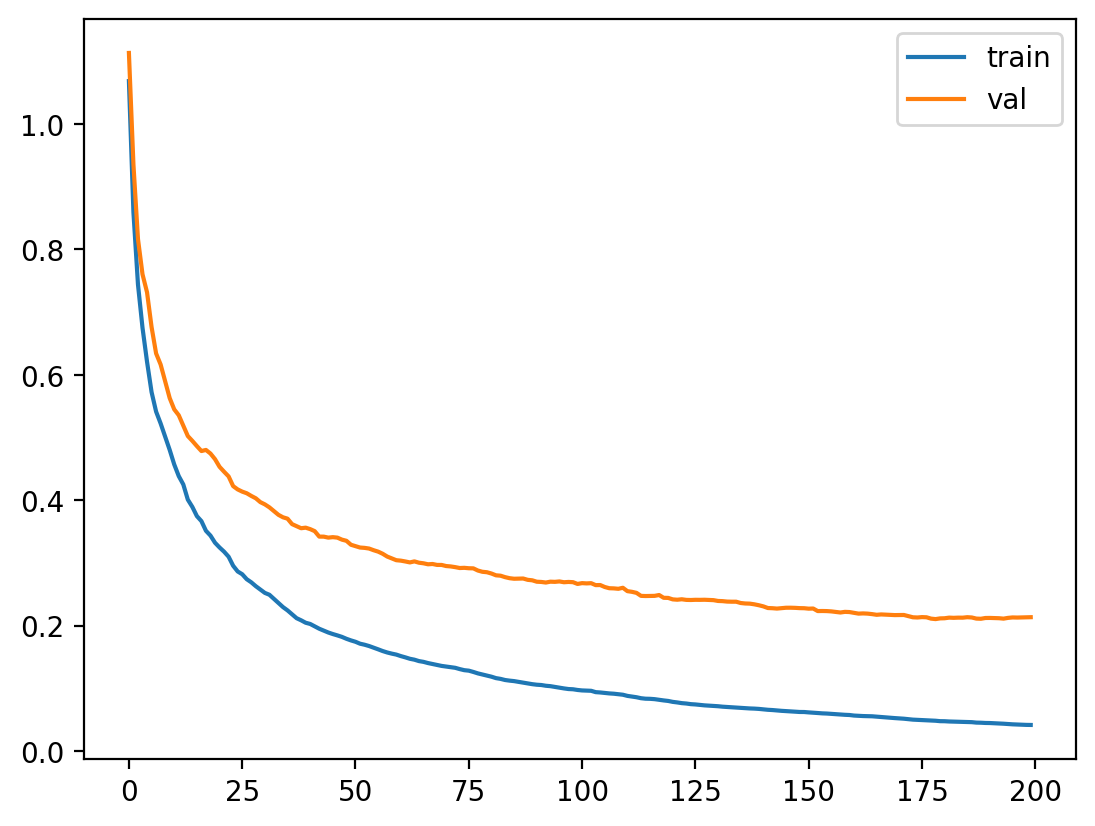

In [162]:
plot_train_and_val_loss(regm)

200


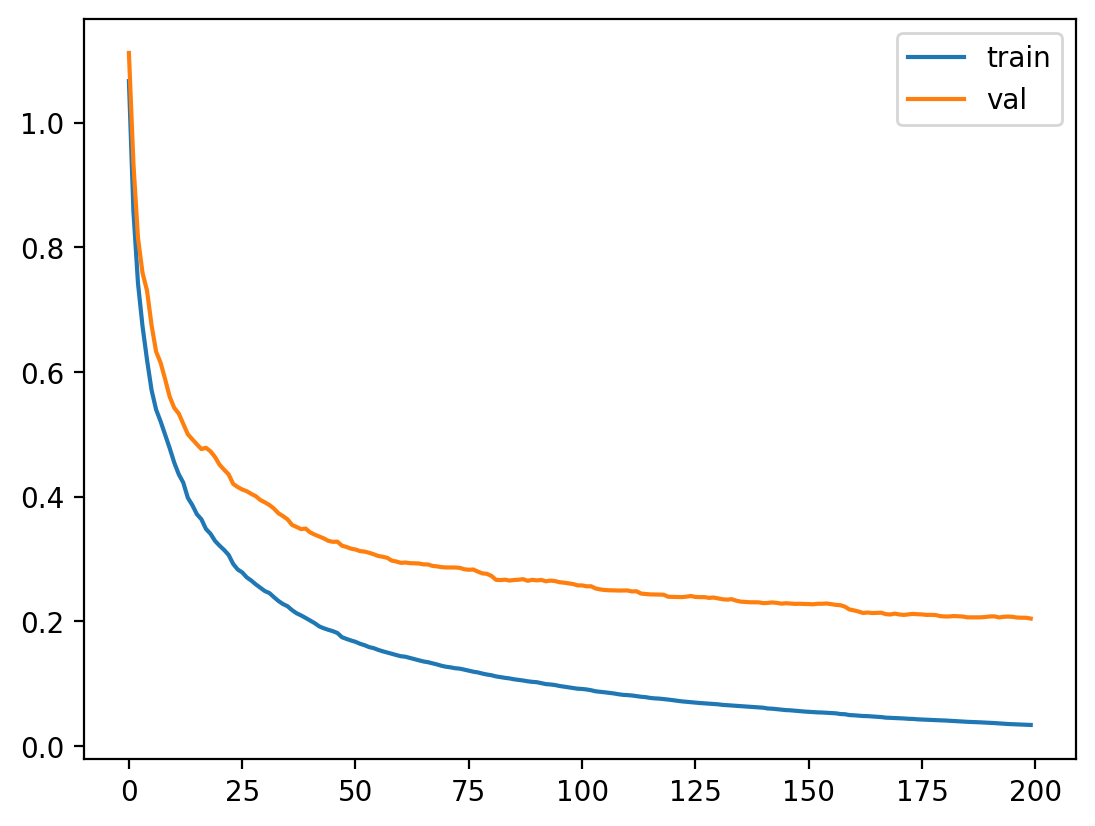

In [163]:

plot_train_and_val_loss(noregm)

In [137]:
regm.get_metadata()['training']

'{"metrics":{"learn_best_error":{"MultiClass":0.04175934863738065},"test_metrics_history":[],"learn_metrics_history":[{"MultiClass":1.0685033846590302},{"MultiClass":0.8590506392915943},{"MultiClass":0.7441066906064386},{"MultiClass":0.6751115687208441},{"MultiClass":0.6208704965517168},{"MultiClass":0.5725582002983243},{"MultiClass":0.541432051457254},{"MultiClass":0.5225468625121903},{"MultiClass":0.5014832316366746},{"MultiClass":0.4803279169674748},{"MultiClass":0.45717473370676004},{"MultiClass":0.43856726977359195},{"MultiClass":0.42528982151316314},{"MultiClass":0.4010954357870964},{"MultiClass":0.3894210986147268},{"MultiClass":0.37478322929842833},{"MultiClass":0.36678639129572554},{"MultiClass":0.3513741374724676},{"MultiClass":0.3437066411934259},{"MultiClass":0.3323245409026254},{"MultiClass":0.32478286470408047},{"MultiClass":0.31807445326736955},{"MultiClass":0.3100142371858682},{"MultiClass":0.2956388417954685},{"MultiClass":0.2865343283151812},{"MultiClass":0.2821357458

In [168]:
regm500 = try_params(
    it=500,
    h=3,
    eta=0.42862401807944406,
    lam=0.5945604135623745,
    verbose=False
)

In [169]:
def regmN(N):
    return try_params(
    it=N,
    h=3,
    eta=0.42862401807944406,
    lam=0.5945604135623745,
    verbose=False
)

1000


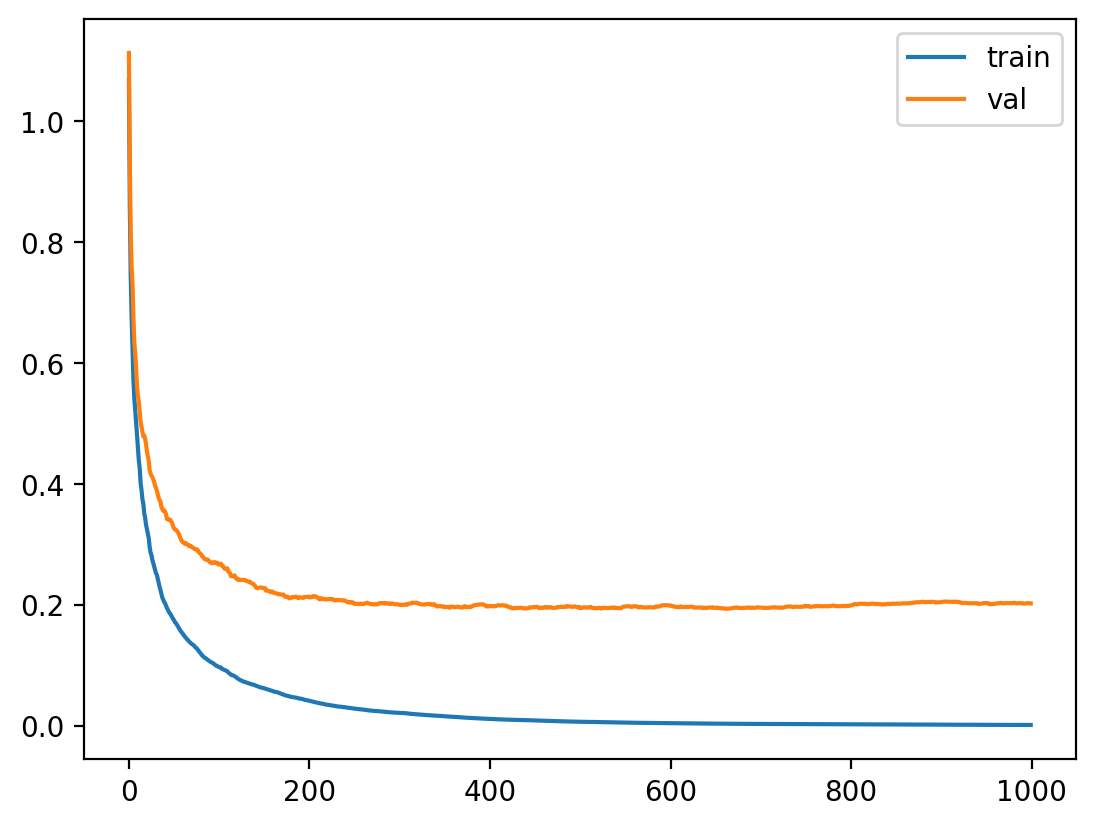

In [171]:

plot_train_and_val_loss(regmN(1000))

In [190]:
def regmhN(h, N):
    return try_params(
    it=N,
    h=h,
    eta=0.42862401807944406,
    lam=0.5945604135623745,
    verbose=False
)

500


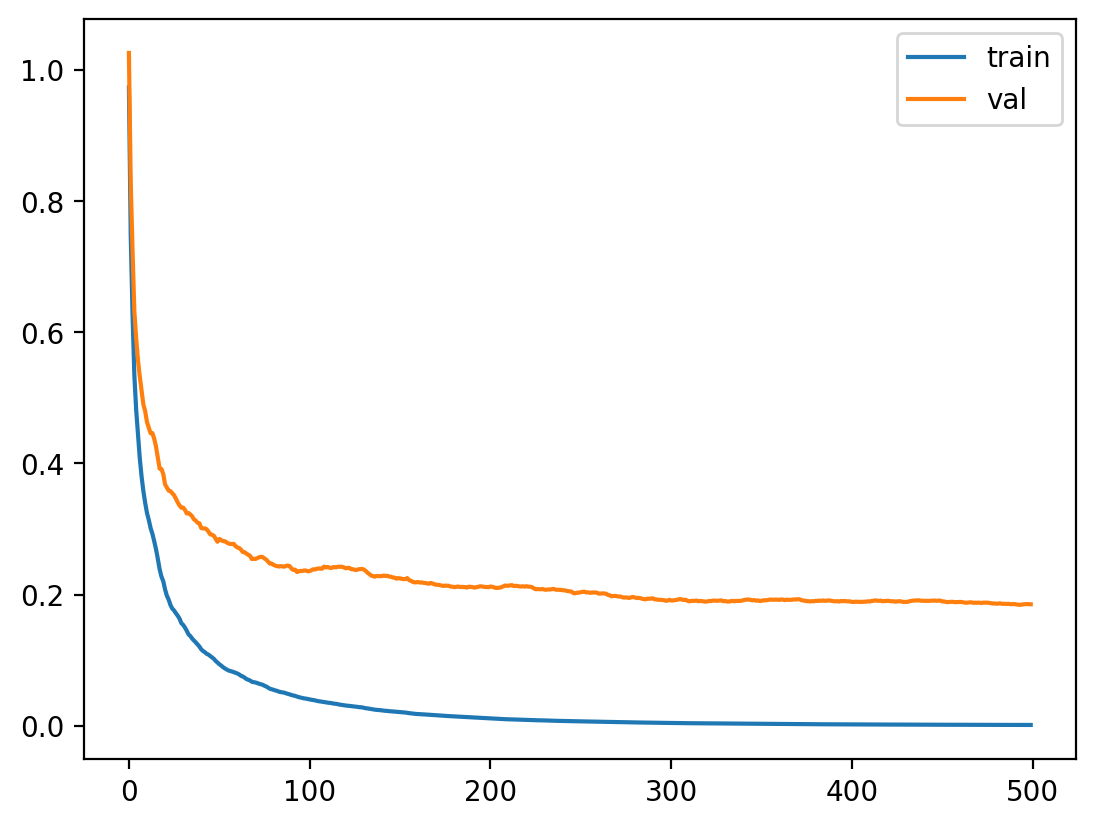

In [175]:
plot_train_and_val_loss(regmhN(5, 500))

500


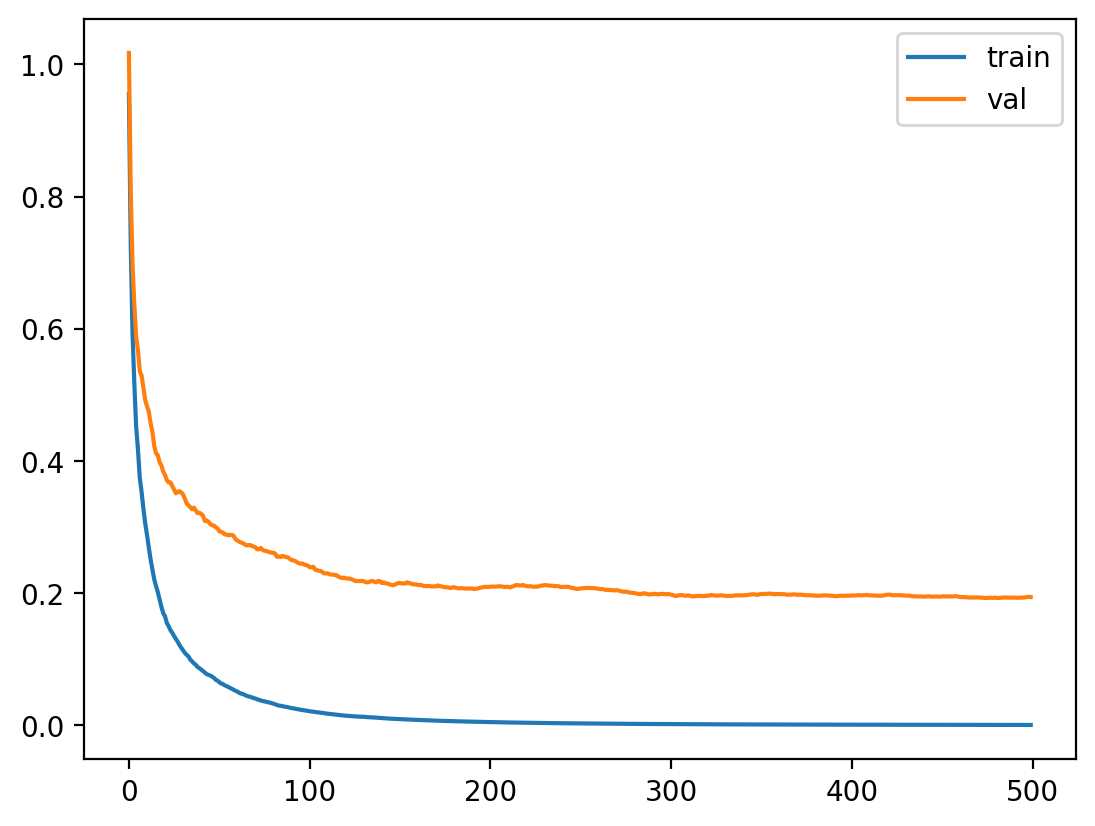

In [176]:

plot_train_and_val_loss(regmhN(6, 500))

In [185]:
def smallregmhN(h, N):
    return try_params(
    it=N,
    h=h,
    eta=0.42862401807944406,
    lam=0.01,
    verbose=False
)

def noregmhN(h, N):
    return try_params(
    it=N,
    h=h,
    eta=0.42862401807944406,
    lam=0.00,
    verbose=False
)

500
500


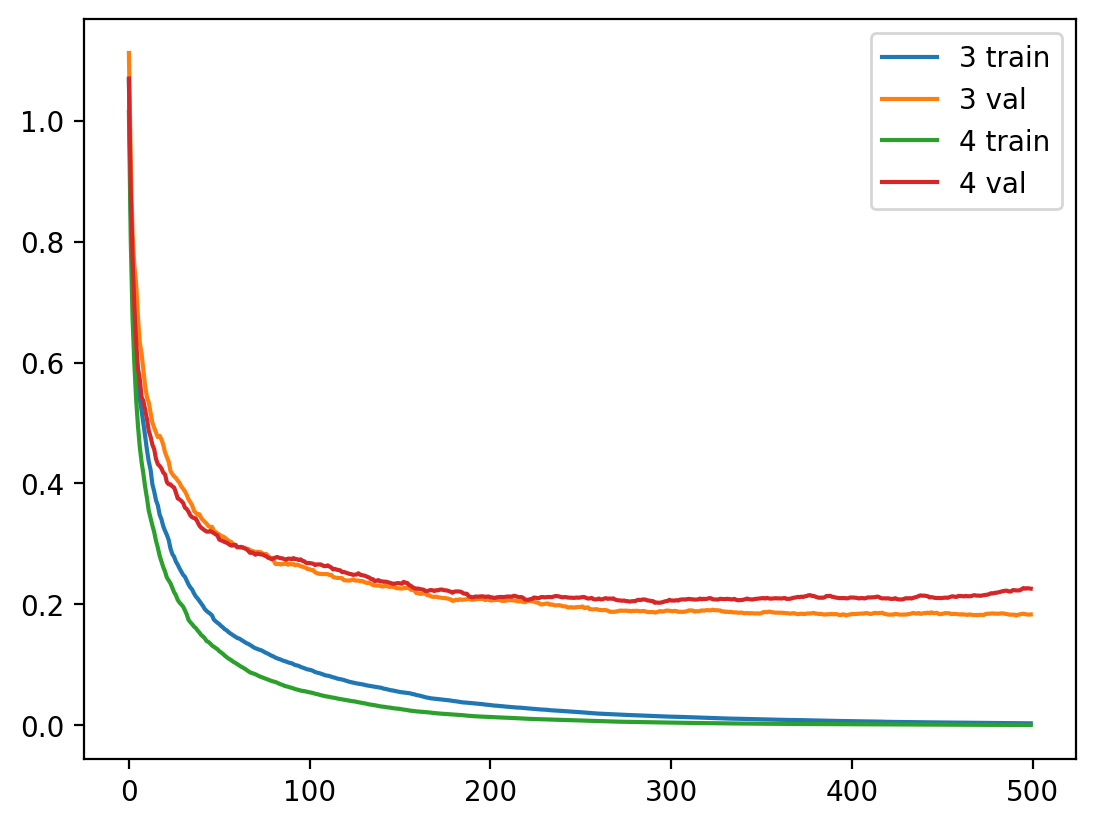

In [184]:
plt.figure(dpi=200)
plot_train_and_val_loss(smallregmhN(3, 500), 3)
plot_train_and_val_loss(smallregmhN(4, 500), 4)
plt.show()

500
500


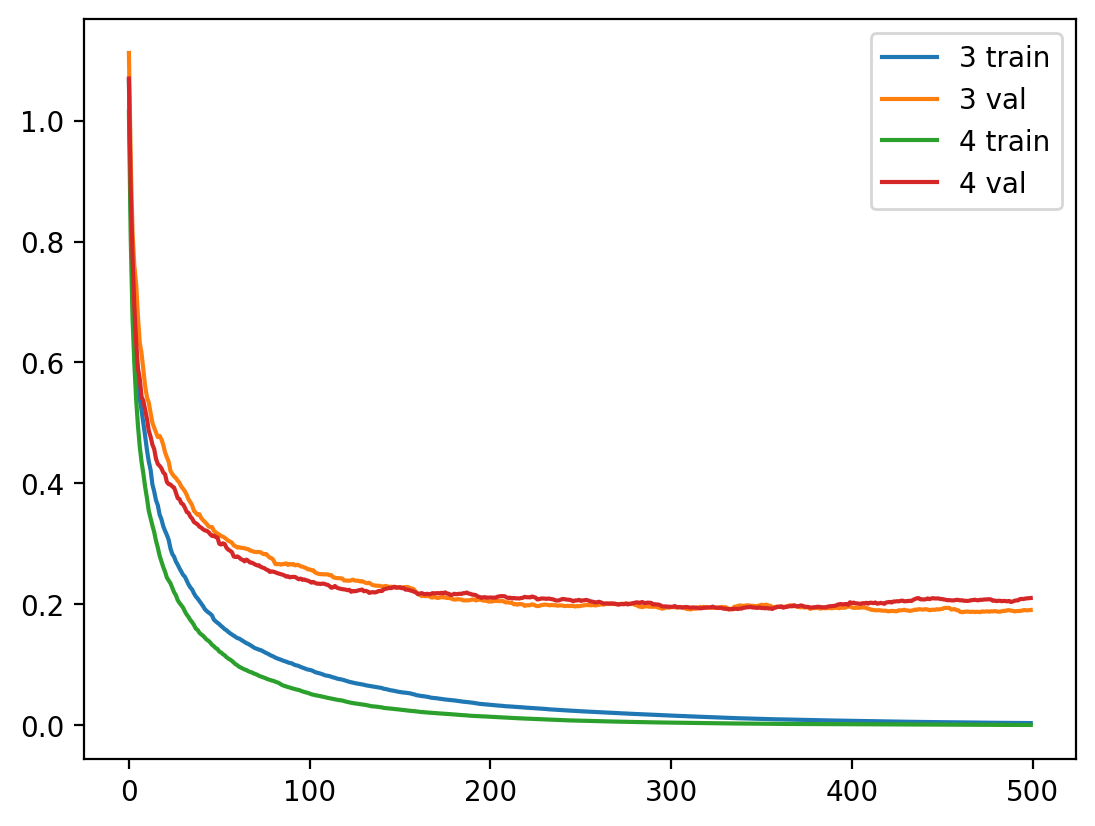

In [186]:
plt.figure(dpi=200)
plot_train_and_val_loss(noregmhN(3, 500), 3)
plot_train_and_val_loss(noregmhN(4, 500), 4)
plt.show()

100


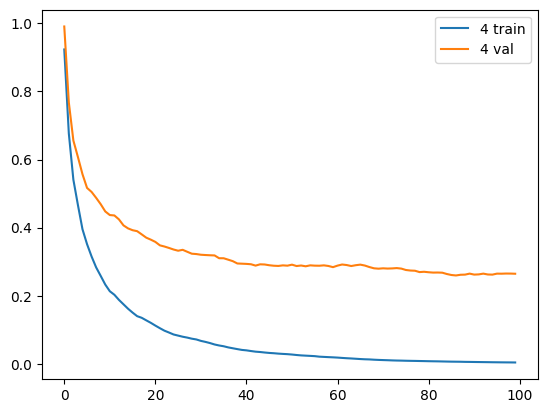

In [187]:
plot_train_and_val_loss(noregmhN(7, 100), 4)

500


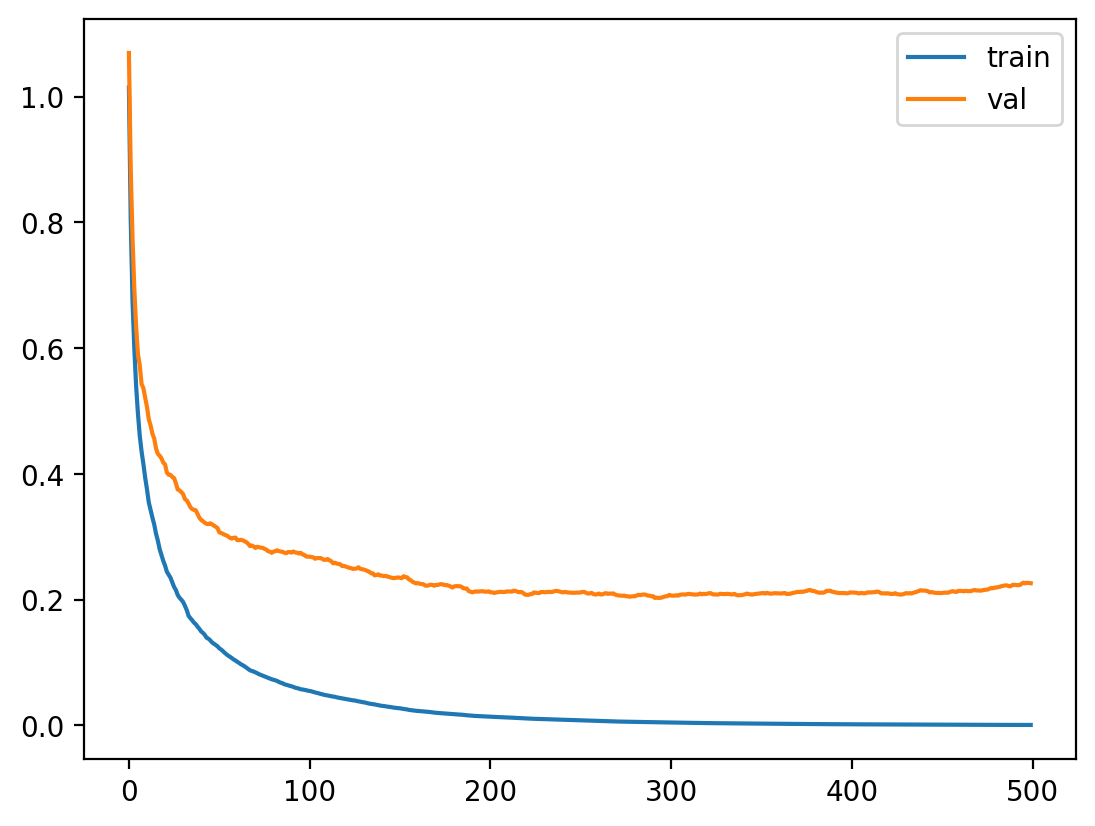

In [179]:
plot_train_and_val_loss(smallregmhN(4, 500))

1000
1000
1000


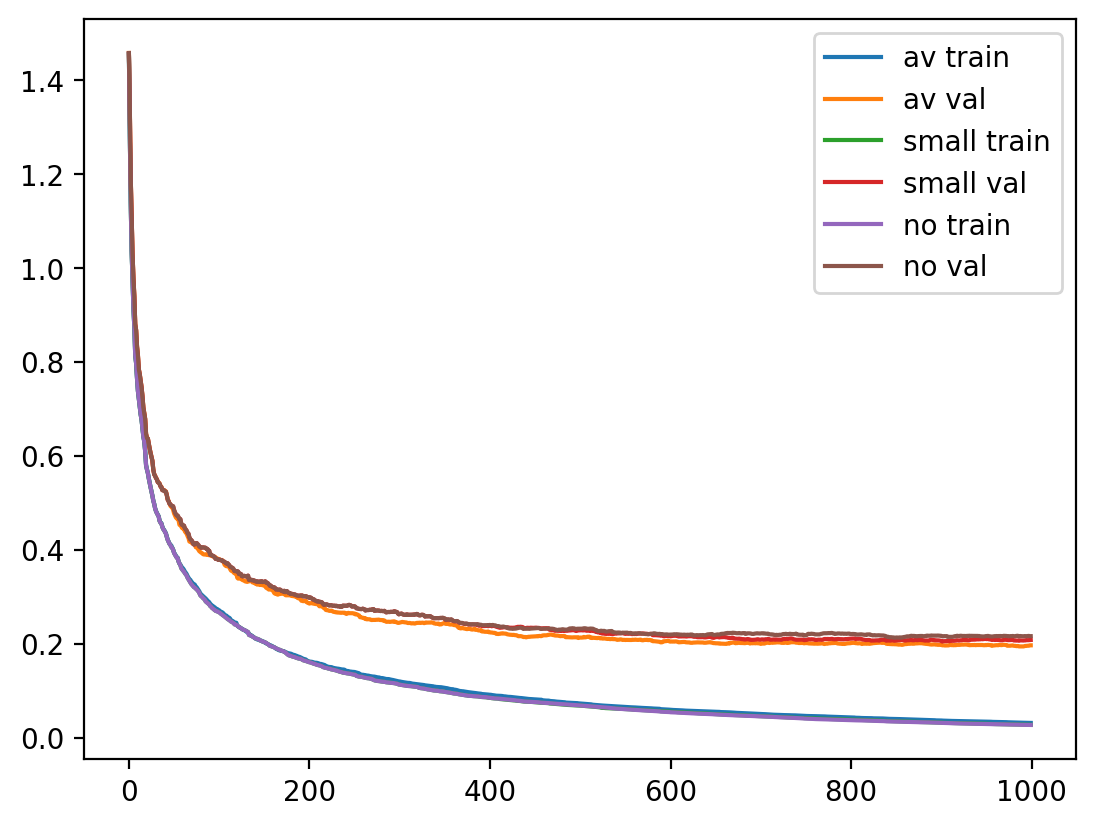

In [189]:
plt.figure(dpi=200)
plot_train_and_val_loss(regmhN(1, 1000), 'av')
plot_train_and_val_loss(smallregmhN(1, 1000), 'small')
plot_train_and_val_loss(noregmhN(1, 1000), 'no')
plt.show()

800
800
800
800
800
800


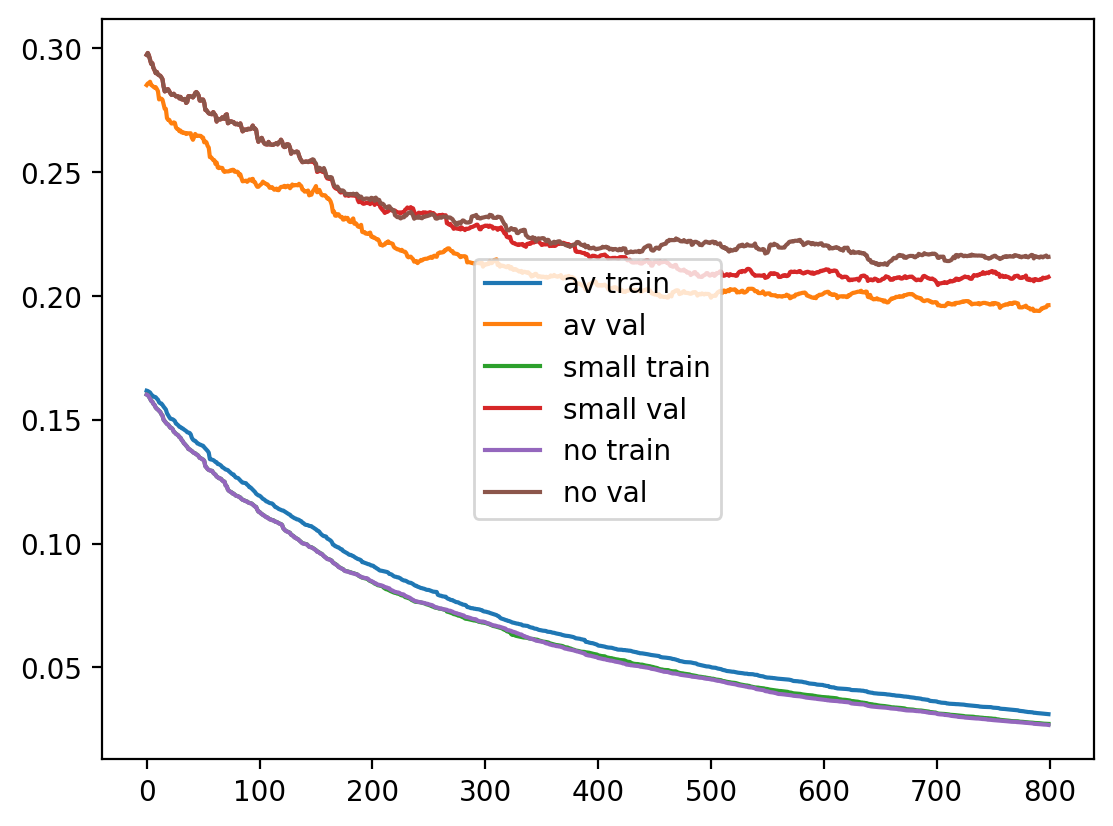

In [196]:
plt.figure(dpi=200)
plot_train_and_val_loss(regmhN(1, 1000), 'av', start=200)
plot_train_and_val_loss(smallregmhN(1, 1000), 'small', start=200)
plot_train_and_val_loss(noregmhN(1, 1000), 'no', start=200)
plt.show()

800
800
800
800
800
800


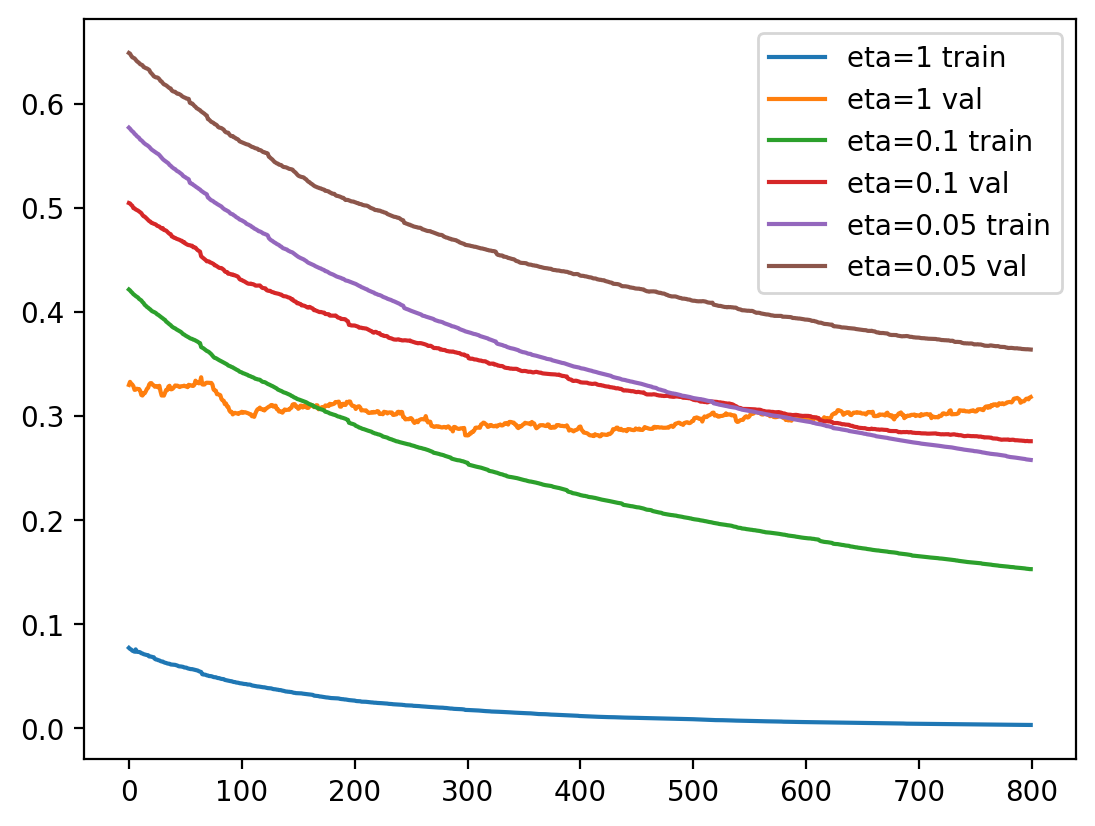

In [195]:
plt.figure(dpi=200)
plot_train_and_val_loss(try_params(h=1, it=1000, eta=1, lam=0.0, verbose=False), 'eta=1', start=200)
plot_train_and_val_loss(try_params(h=1, it=1000, eta=0.1, lam=0.0, verbose=False), 'eta=0.1', start=200)
plot_train_and_val_loss(try_params(h=1, it=1000, eta=0.05, lam=0.0, verbose=False), 'eta=0.05', start=200)
plt.show()

### Conclusion

Please, write down your thoughts on the experiment results:

...

## Part 3. Interpret the model predictions

Train model on original feature set and analyze it.

Please use [shap](https://github.com/slundberg/shap) to build beeswarm plot and at least one of your choice and interpret them (write conclusion).

Explanations of features can be found on dataset's UCI page (see dataset downloading section).

In [ ]:
import shap  # noqa: F401


# YOUR CODE HERE

### Conclusion

Your thoughts about the plots and model behaviour:

...